# 🧠 Module 2 – Session 2 Assignment
# The Decoding Playbook

> **Goal:** Learn how an LLM engineer chooses decoding parameters for different business tasks.

---

## Before You Start

This assignment is **not** asking you to discover the mathematically best temperature.

Instead, imagine you joined a company and your manager asks:

> **"Which decoding settings should we use for each feature, and why?"**

Your job is to justify your engineering decisions with experiments.


# 📖 Story

You work at **Lumen Desk**.

The company has three AI products.

| Product | What the model should do |
|---|---|
| Ticket Tagger | Return ONE category only |
| Reply Drafter | Write a professional reply |
| Campaign Brainstormer | Generate creative marketing ideas |

Notice that these products have **different business goals**, so they probably need **different decoding strategies**.


# 🚀 Roadmap

You will repeat the same workflow three times.

```text
Understand the task
        ↓
Define success
        ↓
Design 3 configurations
        ↓
Run experiments
        ↓
Compare results
        ↓
Choose the winner
        ↓
Write your engineering recommendation
```


In [8]:
%pip install -q torch transformers matplotlib numpy

import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import GPT2LMHeadModel, GPT2Tokenizer

torch.manual_seed(42)

tok = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

model.eval()

print("Setup OK — GPT-2 loaded")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Setup OK — GPT-2 loaded


# Ticket Tagger

## Step 1 — Understand the Business Problem

### Success Criteria

**Exactly one category, deterministic, strict format.**

### Reflection

Answer briefly before moving on:

1. Should the output always be identical?

   yes

2. Is creativity helpful or harmful?

   creativity maybe harmful

3. Should the model take risks?
   
   no

Write your answers below.


---

## Step 2 — Design Three Configurations

You are **not** searching for the correct answer.

Instead, design:

- **Primary** → Your recommendation
- **Challenger A** → A reasonable alternative
- **Challenger B** → Another reasonable alternative

|Configuration|Temperature|Top-k|Top-p|Penalty|Greedy/Sampling|Why?|
|---|---:|---:|---:|---|---|---|
|Primary|0.0|||1.0|greedy|max consistency and stric output|
|Challenger A|0.2|20|0.90|1.0|sampling|test with slight randomes affect|
|Challenger B|0.5|50|0.95|1.0|sampling|more randomes harm strict classification|


---

## Step 3 — Create One Representative Prompt

Choose ONE prompt that realistically represents this product.

```text
Classify this customer support ticket into exactly one category.

Categories:
BILLING
TECHNICAL
ACCOUNT
SHIPPING

Return only the category name.

Ticket:
My order was supposed to arrive yesterday, but I still haven't received it.
```


In [ ]:
# ================================
# Run your experiments here
# ================================

# Suggested workflow
#
# 1. Use the same prompt.
# 2. Run Primary configuration.
# 3. Run Challenger A.
# 4. Run Challenger B.
# 5. If sampling is used:
#       Run AT LEAST 3 times.
#
# Paste or print representative outputs.


In [16]:
def generate_ticket(prompt, temperature=0.0, top_k=50, top_p=1.0,
                    repetition_penalty=1.0, do_sample=False):

    inputs = tok(prompt, return_tensors="pt")

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=do_sample,
            temperature=temperature if do_sample else 1.0,
            top_k=top_k if do_sample else 0,
            top_p=top_p if do_sample else 1.0,
            repetition_penalty=repetition_penalty,
            pad_token_id=tok.eos_token_id
        )

    new_tokens = output[0][inputs["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()

In [17]:
prompt = """Classify this customer support ticket into exactly one category.

Categories:
BILLING
TECHNICAL
ACCOUNT
SHIPPING

Return only the category name.

Ticket:
My order was supposed to arrive yesterday, but I still haven't received it."""

In [21]:
print("Primary")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.0,
        repetition_penalty=1.0,
        do_sample=False
    )

    print(f"\nRun {run}:")
    print(output)

Primary

Run 1:
Return only the category name.

Run 2:
Return only the category name.

Run 3:
Return only the category name.


In [22]:
print("Challenger A ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.2,
        top_k=20,
        top_p=0.90,
        repetition_penalty=1.0,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger A 

Run 1:
Return only the category name.

Run 2:
Return only the category name.

Run 3:
Return only the category name.


In [24]:
print("Challenger B")

for run in range(1, 6):
    output = generate_ticket(
        prompt,
        temperature=0.5,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.0,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger B

Run 1:
Return to top

Categories:

Run 2:
I'm sorry, but I have no idea how

Run 3:
My order was supposed to arrive yesterday,

Run 4:
Return to the Customer Support page.

Run 5:
If you have any questions, please email


---

## Step 4 — Evaluate

Score the behaviour, not factual correctness.

|Configuration|Run|Output Summary|Score|Observation|
|---|---:|---|---:|---|
|Primary|1|Returned Return only the category name.|1/5|Did not return a category|
|Primary|2|Returned Return only the category name.|1/5|Did not follow the required format|
|Primary|3|Returned Return only the category name.|1/5|Did not follow the required format|
|Challenger A|1|Returned Return only the category name.|1/5|Did not return a category|
|Challenger A|2|Returned Return only the category name.|1/5|Did not return a category|
|Challenger A|3|Returned Return only the category name.|1/5|Did not return a category|
|Challenger B|1|Returned Return only the category name.|1/5|Repeated part of the ticket|
|Challenger B|2|Returned My order was supposed to arrive yesterday,|1/5|Repeated part of the ticket|
|Challenger B|3|Returned My order was supposed to arrive yesterday,|1/5|Repeated part of the ticket|

### Questions

- Which configuration won?

Primary won because it was the most consistent and deterministic across all three runs

- Why?

Primary was selected because the Ticket Tagger requires predictable and deterministic behavior.

- Did the evidence surprise you?
  
  Yes,I expected the model to return a category but GPT-2 repeatedly copied parts of the prompt or ticket instead



# Reply Drafter

## Step 1 — Understand the Business Problem

### Success Criteria

**Professional, coherent, polite, natural.**

### Reflection

Answer briefly before moving on:

1. Should the output always be identical?
no
2. Is creativity helpful or harmful?
helpful
3. Should the model take risks? found small risk

Write your answers below.


---

## Step 2 — Design Three Configurations

You are **not** searching for the correct answer.

Instead, design:

- **Primary** → Your recommendation
- **Challenger A** → A reasonable alternative
- **Challenger B** → Another reasonable alternative

|Configuration|Temperature|Top-k|Top-p|Penalty|Greedy/Sampling|Why?|
|---|---:|---:|---:|---|---|---|
|Primary|0.7|50|0.90|1.1|sampling|balance creativity |
|Challenger A|0.4|30|0.85|1.0|sampling|more controlled|
|Challenger B|0.9|80|0.95|1.1|sampling|test with higher creativity " rsponed real replies"|


---

## Step 3 — Create One Representative Prompt

Choose ONE prompt that realistically represents this product.

```text
Write a professional and polite customer support reply to this message.

Customer:
I was charged twice for my monthly subscription. Please help me get a refund for the extra charge.
```


In [ ]:
# ================================
# Run your experiments here
# ================================

# Suggested workflow
#
# 1. Use the same prompt.
# 2. Run Primary configuration.
# 3. Run Challenger A.
# 4. Run Challenger B.
# 5. If sampling is used:
#       Run AT LEAST 3 times.
#
# Paste or print representative outputs.


In [27]:
prompt = """Write a professional and polite customer support reply to this message.

Customer:
I was charged twice for my monthly subscription. Please help me get a refund for the extra charge."""

In [28]:
print(" Primary ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.7,
        top_k=50,
        top_p=0.90,
        repetition_penalty=1.1,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

 Primary 

Run 1:
Thank you!

Run 2:
Thanks,

Run 3:
Thank you very much!

 (1/3


In [29]:
print("Challenger A ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.4,
        top_k=30,
        top_p=0.85,
        repetition_penalty=1.0,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger A 

Run 1:
I was charged twice for my monthly subscription

Run 2:
I was charged twice for my monthly subscription

Run 3:
I am sorry, but I am not


In [30]:
print("Challenger B ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.9,
        top_k=80,
        top_p=0.95,
        repetition_penalty=1.1,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger B 

Run 1:
, You must know about your free trial period

Run 2:
I need your complete agreement before they cancel, but

Run 3:
You should call your billing company immediately so we can


---

## Step 4 — Evaluate

Score the behaviour, not factual correctness.

|Configuration|Run|Output Summary|Score|Observation|
|---|---:|---|---:|---|
|Primary|1|Thank you!|1/5|Polite but too short and doesn't address the refund|
|Primary|2|Thanks|1/5|Incomplete response|
|Primary|3|Thank you very much!|1/5|Polite but doesn't address the issue|
|Challenger A|1|Repeated customer's billing issue|2/5|Relevant but not an actual reply|
|Challenger A|2|Repeated customer's billing issue|2/5|Relevant but doesn't provide a solution|
|Challenger A|3|I am sorry, but I am not|2/5|Starts a polite response but is incomplete|
|Challenger B|1|, You must know about your free trial period|1/5|Irrelevant and unnatural|
|Challenger B|2|I need your complete agreement before they cancel, but|1/5|Incomplete and unclear|
|Challenger B|3|You should call your billing company immediately so we can|1/5|Incomplete and not appropriate for the request|

### Questions

- Which configuration won?
Challenger A performed best overall because its outputs were more relevant to the customer's issue
- Why?
provided the most relevant outputs and showed some awareness of the customer's issue.
- Did the evidence surprise you?
Yes. I expected the higher temperature configuration to produce more natural replies


# Campaign Brainstormer

## Step 1 — Understand the Business Problem

### Success Criteria

**Creative, diverse, non-repetitive.**

### Reflection

Answer briefly before moving on:

1. Should the output always be identical?
no
2. Is creativity helpful or harmful?
helpful
3. Should the model take risks?
yes

Write your answers below.


---

## Step 2 — Design Three Configurations

You are **not** searching for the correct answer.

Instead, design:

- **Primary** → Your recommendation
- **Challenger A** → A reasonable alternative
- **Challenger B** → Another reasonable alternative

|Configuration|Temperature|Top-k|Top-p|Penalty|Greedy/Sampling|Why?|
|---|---:|---:|---:|---|---|---|
|Primary|0.8|50|0.95|1.2|sampling|relevance and balanced |
|Challenger A|0.6|40|0.90|1.1|sampling|test with lowe randomes and more useful idea|
|Challenger B|1.0|100|0.98|1.2|sampling|test with higer // and more creative idea|


---

## Step 3 — Create One Representative Prompt

Choose ONE prompt that realistically represents this product.

```text
WBrainstorm 5 creative marketing campaign ideas for a new eco-friendly reusable water bottle aimed at college students.

For each idea, provide:
- A short tagline
- A one-sentence concept.
```


In [ ]:
# ================================
# Run your experiments here
# ================================

# Suggested workflow
#
# 1. Use the same prompt.
# 2. Run Primary configuration.
# 3. Run Challenger A.
# 4. Run Challenger B.
# 5. If sampling is used:
#       Run AT LEAST 3 times.
#
# Paste or print representative outputs.


In [31]:
prompt = """Brainstorm 5 creative marketing campaign ideas for a new eco-friendly reusable water bottle aimed at college students.

For each idea, provide:
- A short tagline
- A one-sentence concept."""

In [32]:
print(" Primary ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.8,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

 Primary 

Run 1:
Write it down in front of your computer screen and

Run 2:
Submit with your name and email address in an e

Run 3:
It will be featured in your blog post or book


In [33]:
print("Challenger A ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=0.6,
        top_k=40,
        top_p=0.90,
        repetition_penalty=1.1,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger A 

Run 1:
(If you're working on something else that's

Run 2:
The project will be reviewed by the team of scientists

Run 3:
Please include links to the original work of this article


In [34]:
print("Challenger B ")

for run in range(1, 4):
    output = generate_ticket(
        prompt,
        temperature=1.0,
        top_k=100,
        top_p=0.98,
        repetition_penalty=1.2,
        do_sample=True
    )

    print(f"\nRun {run}:")
    print(output)

Challenger B 

Run 1:
What's your brand in this space? Tell us

Run 2:
We will post it on our blog and tweet about

Run 3:
We will discuss our most popular features in 3 phases


---

## Step 4 — Evaluate

Score the behaviour, not factual correctness.

|Configuration|Run|Output Summary|Score|Observation|
|---|---:|---|---:|---|
|Primary|1|Write it down in front of your computer screen and|1/5|Irrelevant and incomplete|
|Primary|2|Submit with your name and email address in an e|1/5|Irrelevant and incomplete|
|Primary|3|It will be featured in your blog post or book|1/5|Irrelevant and incomplete|
|Challenger A|1|(If you're working on something else that's|1/5|Irrelevant and incomplete|
|Challenger A|2|The project will be reviewed by the team of scientists|1/5|Irrelevant to the marketing task|
|Challenger A|3|Please include links to the original work of this article|1/5|Irrelevant and incomplete|
|Challenger B|1|What's your brand in this space? Tell us|2/5|Some marketing relevance, but incomplete|
|Challenger B|2|We will post it on our blog and tweet about|2/5|Marketing-related but incomplete|
|Challenger B|3|We will discuss our most popular features in 3 phases|2/5|Some campaign-like language, but incomplete|

### Questions

- Which configuration won?
Challenger B won because it produced the most marketing-related outputs and showed more useful variation than Primary and Challenger A
- Why?
the highest temperature and produced more varied outputs that were closer to the marketing context
- Did the evidence surprise you?
Yes. I expected higher temperature to produce more creative campaign ideas, but the outputs were still incomplete


# 📝 Part C — The Decoding Playbook

Imagine a new engineer joins your team tomorrow.

They should be able to use this page **without reading the rest of the notebook.**

## Final Recommendations

|Feature|Recommended Configuration|Reason|
|---|---|---|
|Ticket Tagger|Primary: T=0.0, Greedy|Deterministic and consistent behavior is important for strict category output.|
|Reply Drafter|Challenger A: T=0.4, Top-k=30, Top-p=0.85, Sampling|More controlled generation produced more relevant outputs than the higher-temperature option.|
|Campaign Brainstormer|Challenger B: T=1.0, Top-k=100, Top-p=0.98, Sampling|Produced the most marketing-related variation and was the most creative of the tested configurations.|

---

## House Rule #1

Example:

> Use deterministic decoding when output format is strict.

Write your own:
when the output format is strict and consistency is more important than creativity

---

## House Rule #2

Example:

> Use sampling only when diversity creates business value.

Write your own.

when diversity and creativity create business value, but keep randomness controlled enough to maintain relevance.

---

## Biggest Limitation

Choose one and explain why it matters.

- GPT-2 is a small model
- Small sample size
- Subjective scoring
- Other

A major limitation is that GPT-2 is a small base language model and is not instruction-tuned. This affected the experiments because the model often continued or repeated text instead of following the task instructions

# ✅ Submission Checklist

- [ ] I defined success criteria before testing.
- [ ] I designed three configurations for every feature.
- [ ] Every stochastic configuration was executed at least three times.
- [ ] I scored outputs before deciding the winner.
- [ ] My final playbook is self-contained.
- [ ] All notebook cells are executed.

---

## ⭐ Bonus (Optional)

Complete ONE:

- Compare Greedy vs Sampling visually.
- Plot the effect of different temperatures.
- Demonstrate reproducibility using random seeds.
- Show a challenger configuration outperforming your primary recommendation.


In [37]:
# Bonus 1

prompt = """Brainstorm 5 creative marketing campaign ideas for a new eco-friendly reusable water bottle aimed at college students.

For each idea, provide:
- A short tagline
- A one-sentence concept."""

# Greedy generation
greedy_outputs = []

for i in range(3):
    output = generate_ticket(
        prompt,
        temperature=0.0,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.0,
        do_sample=False
    )
    greedy_outputs.append(output)

# Sampling generation
sampling_outputs = []

for i in range(3):
    output = generate_ticket(
        prompt,
        temperature=0.8,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.2,
        do_sample=True
    )
    sampling_outputs.append(output)

print("GREEDY ")
for i, output in enumerate(greedy_outputs, 1):
    print(f"\nRun {i}:")
    print(output)

print("\n SAMPLING ")
for i, output in enumerate(sampling_outputs, 1):
    print(f"\nRun {i}:")
    print(output)

GREEDY 

Run 1:
- A link to a website with a

Run 2:
- A link to a website with a

Run 3:
- A link to a website with a

 SAMPLING 

Run 1:
Write it down and then give your project the credit

Run 2:
Examples include "Bring back the old Coca Cola

Run 3:
We will take the time to review your suggestions and


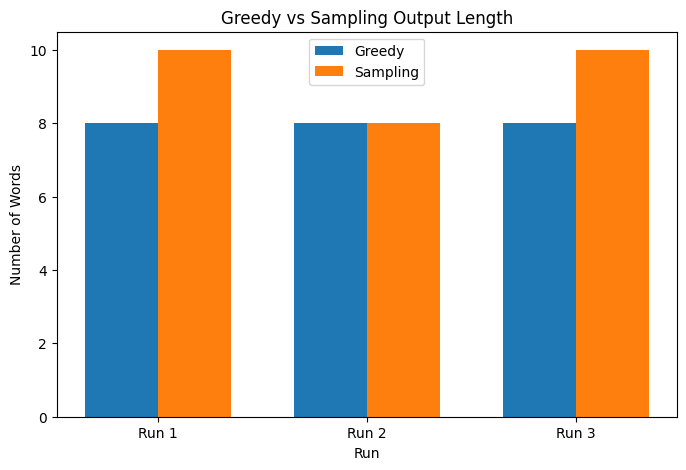

In [38]:
# visual comparison

greedy_lengths = [len(output.split()) for output in greedy_outputs]
sampling_lengths = [len(output.split()) for output in sampling_outputs]

labels = ["Run 1", "Run 2", "Run 3"]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, greedy_lengths, width, label="Greedy")
plt.bar(x + width/2, sampling_lengths, width, label="Sampling")

plt.xlabel("Run")
plt.ylabel("Number of Words")
plt.title("Greedy vs Sampling Output Length")
plt.xticks(x, labels)
plt.legend()

plt.show()

In [35]:
# Bonus 3

torch.manual_seed(42)

output1 = generate_ticket(
    prompt,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    repetition_penalty=1.2,
    do_sample=True
)

torch.manual_seed(42)

output2 = generate_ticket(
    prompt,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    repetition_penalty=1.2,
    do_sample=True
)

print("Output 1:")
print(output1)

print("\nOutput 2:")
print(output2)

print("\nAre they identical?", output1 == output2)

Output 1:
The project could be applied to any subject or topic

Output 2:
The project could be applied to any subject or topic

Are they identical? True


Observation

Both outputs were identical when the same random seed and decoding configuration were used. This demonstrates that sampling can be reproducible when the random state is controlled.